In [1]:
from sklearn.datasets import fetch_openml
# Fetches the 70,000 handwritten digit images from OpenML
mnist_data = fetch_openml('mnist_784', version=1, as_frame=False)

Step 1: Baseline Model Training

In [23]:
# Split the data into training and test sets
from sklearn.model_selection import train_test_split

X = mnist_data.data
y = mnist_data.target

# Keep a small test set for checking accuracy
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [7]:
#todo - train 2 distinct algorithms with baseline/default settings to establish performance benchmarks.
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

baseline_models = {
    "SGDClassifier": SGDClassifier(random_state=42),
    "RandomForestClassifier": RandomForestClassifier(random_state=42),
}

for name, model in baseline_models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    print(f"{name} accuracy: {accuracy:.4f}")


SGDClassifier accuracy: 0.8744
RandomForestClassifier accuracy: 0.9672


In [8]:
#todo - SGDClassifier - linear classifier using stochastic gradient descent

from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

sgd_model = SGDClassifier(random_state=42)
sgd_model.fit(X_train, y_train)

sgd_predictions = sgd_model.predict(X_test)
sgd_accuracy = accuracy_score(y_test, sgd_predictions)
print("SGD accuracy:", sgd_accuracy)


SGD accuracy: 0.8743571428571428


# Train a simple SGD model
#todo - SGDClassifier - linear classifier using stochastic gradient descent

from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

sgd_model = SGDClassifier(random_state=42)
sgd_model.fit(X_train, y_train)

# Check how well the model predicts the test data
sgd_predictions = sgd_model.predict(X_test)
sgd_accuracy = accuracy_score(y_test, sgd_predictions)
print("SGD accuracy:", sgd_accuracy)


In [10]:
#todo - RandomForestClassifier - ensemble method using decision trees

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)
print("Random Forest accuracy:", rf_accuracy)


Random Forest accuracy: 0.9672142857142857


In [11]:
# Train a simple Random Forest model
#todo - RandomForestClassifier - ensemble method using decision trees

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Check how well the model predicts the test data
rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)
print("Random Forest accuracy:", rf_accuracy)


Random Forest accuracy: 0.9672142857142857


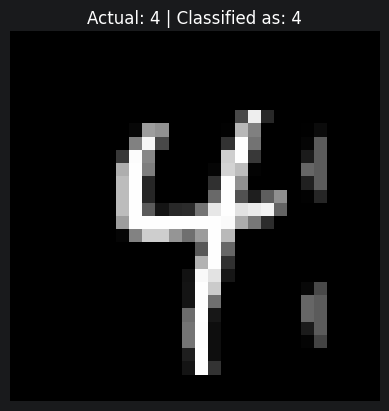

In [24]:
# Pick a random digit and show it
import random
import matplotlib.pyplot as plt

# Display one random image
def show_random_digit():
    # Choose a random index
    index = random.randint(0, len(X_test) - 1)
    
    # Get the image and label
    image = X_test[index].reshape(28, 28)
    actual_label = y_test[index]
    predicted_label = rf_model.predict([X_test[index]])[0]
    
    # Plot the digit
    plt.imshow(image, cmap='gray')
    plt.axis('off')
    plt.title(f'Actual: {actual_label} | Classified as: {predicted_label}')
    plt.show()

# Run it once
show_random_digit()


In [13]:
# Make a simple button widget
import ipywidgets as widgets
from IPython.display import display, clear_output

# Create a button that shows another random digit
button = widgets.Button(description='Show random digit')
output = widgets.Output()

def on_button_click(button):
    # Clear old output first
    with output:
        clear_output(wait=True)
        
        # Pick a random digit and show it
        index = random.randint(0, len(X_test) - 1)
        image = X_test[index].reshape(28, 28)
        actual_label = y_test[index]
        predicted_label = rf_model.predict([X_test[index]])[0]
        
        # Draw the image in the output area
        fig, ax = plt.subplots()
        ax.imshow(image, cmap='gray')
        ax.axis('off')
        ax.set_title(f'Actual: {actual_label} | Classified as: {predicted_label}')
        display(fig)
        plt.close(fig)

# Link the button to the function
button.on_click(on_button_click)
display(button)
display(output)


Button(description='Show random digit', style=ButtonStyle())

Output()

Step 2: Feature Engineering and Scaling options

In [14]:
# Pixel Intensity Scaling - divide raw values by 255 to scale them to the range [0, 1]
# This stabilizes gradient paths by normalizing pixel intensity values from 0-255 to 0.0-1.0
X_train_scaled = X_train / 255.0
X_test_scaled = X_test / 255.0

print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_train scaled min: {X_train_scaled.min()}, max: {X_train_scaled.max()}")


X_train shape: (56000, 784)
X_train scaled min: 0.0, max: 1.0


In [15]:
# Dimensionality Reduction with PCA
# Transform the 784-pixel layout into a smaller set of principal components that retain the highest dataset variance while filtering background noise
from sklearn.decomposition import PCA

# Create a PCA model that retains 95% of the variance
# This reduces dimensionality from 784 features to ~150 principal components
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original shape: {X_train_scaled.shape}")
print(f"PCA shape: {X_train_pca.shape}")
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.4f}")
print(f"Number of components: {pca.n_components_}")


Original shape: (56000, 784)
PCA shape: (56000, 154)
Variance explained: 0.9504
Number of components: 154


Step 3: Hyperparameter Tuning and Optimization
 --> systematically adjust the algorithms control settings to find the optimal balance between underfotting and overfitting.

In [16]:
#todo - loss function and penalty tuning: alternate loss arguments (comparing 'hinge' vs 'log_loss') and adjust the regularization scale (alpha) to prevent over-memorizing pixel patterns

from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

results = []
for loss in ["hinge", "log_loss"]:
    for alpha in [0.0001, 0.001, 0.01]:
        model = SGDClassifier(
            loss=loss,
            alpha=alpha,
            random_state=42,
            max_iter=1000,
            tol=1e-3
        )
        model.fit(X_train_pca, y_train)
        predictions = model.predict(X_test_pca)
        accuracy = accuracy_score(y_test, predictions)
        results.append((loss, alpha, accuracy))
        print(f"loss={loss}, alpha={alpha}, accuracy={accuracy:.4f}")

best_loss, best_alpha, best_accuracy = max(results, key=lambda item: item[2])
print(f"Best settings: loss={best_loss}, alpha={best_alpha}, accuracy={best_accuracy:.4f}")


loss=hinge, alpha=0.0001, accuracy=0.9115
loss=hinge, alpha=0.001, accuracy=0.9116
loss=hinge, alpha=0.01, accuracy=0.9031
loss=log_loss, alpha=0.0001, accuracy=0.9136
loss=log_loss, alpha=0.001, accuracy=0.9094
loss=log_loss, alpha=0.01, accuracy=0.8926
Best settings: loss=log_loss, alpha=0.0001, accuracy=0.9136


In [17]:
#todo - Threshold & Class imbalance adjustments: fine-tune decision boundaries along the precision recall curve to improve classification of underrepresented digits (e.g., 0, 1, 2)

from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report

imbalanced_model = SGDClassifier(
    loss="log_loss",
    alpha=0.001,
    class_weight="balanced",
    random_state=42,
    max_iter=1000,
    tol=1e-3
)
imbalanced_model.fit(X_train_pca, y_train)

imbalanced_predictions = imbalanced_model.predict(X_test_pca)
print(classification_report(y_test, imbalanced_predictions, labels=[0, 1, 2]))


              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1381
           1       0.97      0.96      0.96      1575
           2       0.90      0.88      0.89      1398

   micro avg       0.94      0.93      0.94      4354
   macro avg       0.94      0.93      0.94      4354
weighted avg       0.94      0.93      0.94      4354



In [18]:
# use an automated grid search to test multiple values for the regularization parameter to see which setting yields the validation F1 score.

import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import SGDClassifier

# Use a smaller sample to keep the notebook responsive while still demonstrating the search.
sample_size = 10000
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_train_pca), size=sample_size, replace=False)

X_train_sample = X_train_pca[sample_idx]
y_train_sample = y_train[sample_idx]

param_grid = {
    "loss": ["hinge", "log_loss"],
    "alpha": [0.0001, 0.001, 0.01],
}

grid_search = GridSearchCV(
    SGDClassifier(random_state=42, max_iter=1000, tol=1e-3),
    param_grid=param_grid,
    scoring="f1_macro",
    cv=2,
    n_jobs=-1,
)
grid_search.fit(X_train_sample, y_train_sample)

print("Best parameters:", grid_search.best_params_)
print("Best F1 macro:", round(grid_search.best_score_, 4))


Best parameters: {'alpha': 0.001, 'loss': 'log_loss'}
Best F1 macro: 0.8869


Step 4: Advanced Ensemble Techniques --> combine multiple models to improve overall performance and robustness.

In [19]:
#todo - Voting Classifier - combine predictions from multiple models to improve accuracy and reduce variance

from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

voting_model = VotingClassifier(
    estimators=[
        ("sgd", SGDClassifier(loss="log_loss", alpha=0.001, random_state=42, max_iter=1000, tol=1e-3)),
        ("rf", RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1)),
    ],
    voting="hard",
)
voting_model.fit(X_train_pca, y_train)

voting_predictions = voting_model.predict(X_test_pca)
voting_accuracy = accuracy_score(y_test, voting_predictions)
print("Voting accuracy:", voting_accuracy)


Voting accuracy: 0.93


In [20]:
#todo - Random Forest - ensemble method using bootstrap sampling to stabilze predictions and reduce overfitting

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_ensemble_model = RandomForestClassifier(
    random_state=42,
    n_estimators=200,
    n_jobs=-1
)
rf_ensemble_model.fit(X_train_pca, y_train)

rf_ensemble_predictions = rf_ensemble_model.predict(X_test_pca)
rf_ensemble_accuracy = accuracy_score(y_test, rf_ensemble_predictions)
print("Random Forest ensemble accuracy:", rf_ensemble_accuracy)


Random Forest ensemble accuracy: 0.9487857142857142


In [21]:
#todo - Stacking Architecture - pass predictions from several base models as input features to a meta-model that learns to make final predictions based on the strengths of each base model.

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

stacking_model = StackingClassifier(
    estimators=[
        ("sgd", SGDClassifier(loss="log_loss", alpha=0.001, random_state=42, max_iter=1000, tol=1e-3)),
        ("rf", RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1)),
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=2
)
stacking_model.fit(X_train_pca, y_train)

stacking_predictions = stacking_model.predict(X_test_pca)
stacking_accuracy = accuracy_score(y_test, stacking_predictions)
print("Stacking accuracy:", stacking_accuracy)


Stacking accuracy: 0.9492142857142857


In [22]:
#example: implement a soft-voting classifier that averages the predictions probabilities of your tuned SGD and Random Forest models to produce a final prediction for each digit image.